In [1]:
import sys
import os
os.chdir("../src")
sys.path.append("../utils")
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['14.91GB', '42.41GB']


In [3]:
import visualization as vsd
import initial_conditions as ic
from sdfb_simulator import SPD_Simulator

In [4]:
N0=64
t=1
n=10
times={}
def compute_times(t_int,ps,n,steps,scheme):
    for p in ps:
        times[(p,t_int)]=np.arange(n)
        for i in np.arange(n):
            N=2**(i+3)//(p+1)
            print(p,N)
            s = SPD_Simulator(p=p,N=(N,N),time_integrator=t_int,cfl_coeff=1.6//(p+1),scheme=scheme)
            s.perform_iterations(steps)
            times[(p,t_int)][i]=s.zone_cycles

In [5]:
compute_times("rk4",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 1.441, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.364, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.362, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.362, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.362, bzcps = 0.001
3 64
t=0.0, steps taken 100, time taken 1.368, bzcps = 0.005
3 128
t=0.0, steps taken 100, time taken 1.381, bzcps = 0.019
3 256
t=0.0, steps taken 100, time taken 1.848, bzcps = 0.057
3 512
t=0.0, steps taken 100, time taken 6.779, bzcps = 0.062
3 1024
t=0.0, steps taken 100, time taken 26.672, bzcps = 0.063
7 1
t=0.0, steps taken 100, time taken 1.387, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 1.373, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 1.367, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 1.356, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 1.37, bzcps = 0.001
7 32
t=0.0, steps taken 100, time taken 1.371, bzcps = 0.005
7 64
t=0.0, steps taken 100, time taken 1.

In [6]:
compute_times("ader",[3,7],n-1,100,"SD")

3 2
t=0.0, steps taken 100, time taken 1.202, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.192, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.192, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.197, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.199, bzcps = 0.001
3 64
t=0.0, steps taken 100, time taken 1.201, bzcps = 0.005
3 128
t=0.0, steps taken 100, time taken 1.336, bzcps = 0.02
3 256
t=0.0, steps taken 100, time taken 4.602, bzcps = 0.023
3 512
t=0.0, steps taken 100, time taken 18.842, bzcps = 0.022
7 1
t=0.0, steps taken 100, time taken 1.904, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 1.869, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 1.868, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 1.867, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 1.879, bzcps = 0.001
7 32
t=0.0, steps taken 100, time taken 1.875, bzcps = 0.003
7 64
t=0.0, steps taken 100, time taken 2.552, bzcps = 0.01
7 128
t=0.0, steps taken 100, time taken 9.96

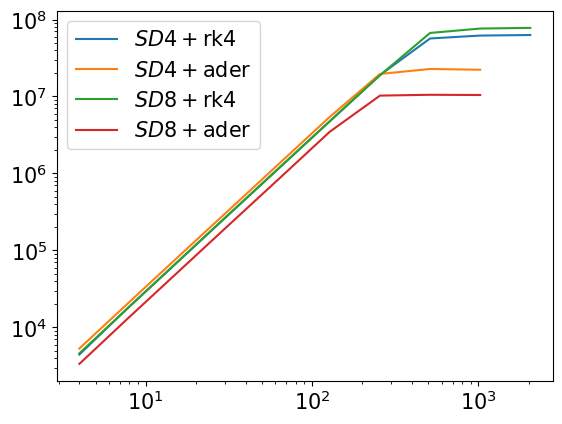

In [7]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    for t_int in ["rk4","ader"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
plt.yscale("log")
plt.xscale("log")
plt.legend()

In [8]:
compute_times("rk3",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 1.053, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.043, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.044, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.044, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.043, bzcps = 0.002
3 64
t=0.0, steps taken 100, time taken 1.049, bzcps = 0.006
3 128
t=0.0, steps taken 100, time taken 1.056, bzcps = 0.025
3 256
t=0.0, steps taken 100, time taken 1.389, bzcps = 0.076
3 512
t=0.0, steps taken 100, time taken 5.12, bzcps = 0.082
3 1024
t=0.0, steps taken 100, time taken 20.306, bzcps = 0.083
7 1
t=0.0, steps taken 100, time taken 1.058, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 1.047, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 1.041, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 1.048, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 1.047, bzcps = 0.002
7 32
t=0.0, steps taken 100, time taken 1.042, bzcps = 0.006
7 64
t=0.0, steps taken 100, time taken 1.

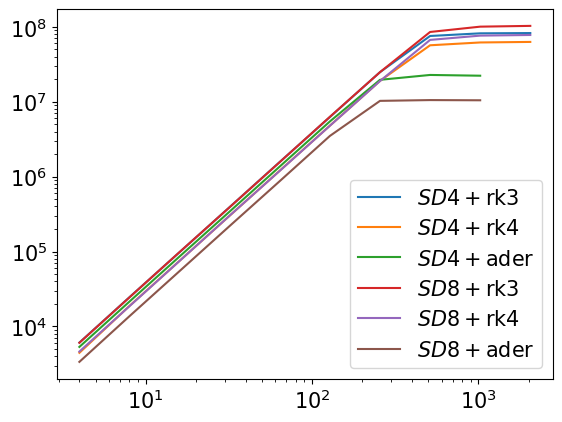

In [9]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    for t_int in ["rk3","rk4","ader"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
plt.yscale("log")
plt.xscale("log")
plt.legend()

In [10]:
compute_times("rk1",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 0.406, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 0.4, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 0.4, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 0.412, bzcps = 0.001
3 32
t=0.0, steps taken 100, time taken 0.399, bzcps = 0.004
3 64
t=0.0, steps taken 100, time taken 0.399, bzcps = 0.016
3 128
t=0.0, steps taken 100, time taken 0.408, bzcps = 0.064
3 256
t=0.0, steps taken 100, time taken 0.595, bzcps = 0.176
3 512
t=0.0, steps taken 100, time taken 2.024, bzcps = 0.207
3 1024
t=0.0, steps taken 100, time taken 7.858, bzcps = 0.213
7 1
t=0.0, steps taken 100, time taken 0.407, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 0.403, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 0.414, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 0.402, bzcps = 0.001
7 16
t=0.0, steps taken 100, time taken 0.404, bzcps = 0.004
7 32
t=0.0, steps taken 100, time taken 0.402, bzcps = 0.016
7 64
t=0.0, steps taken 100, time taken 0.

In [11]:
compute_times("rk2",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 0.714, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 0.732, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 0.721, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 0.72, bzcps = 0.001
3 32
t=0.0, steps taken 100, time taken 0.724, bzcps = 0.002
3 64
t=0.0, steps taken 100, time taken 0.727, bzcps = 0.009
3 128
t=0.0, steps taken 100, time taken 0.731, bzcps = 0.036
3 256
t=0.0, steps taken 100, time taken 0.996, bzcps = 0.105
3 512
t=0.0, steps taken 100, time taken 3.552, bzcps = 0.118
3 1024
t=0.0, steps taken 100, time taken 14.26, bzcps = 0.118
7 1
t=0.0, steps taken 100, time taken 0.728, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 0.724, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 0.719, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 0.721, bzcps = 0.001
7 16
t=0.0, steps taken 100, time taken 0.721, bzcps = 0.002
7 32
t=0.0, steps taken 100, time taken 0.721, bzcps = 0.009
7 64
t=0.0, steps taken 100, time taken

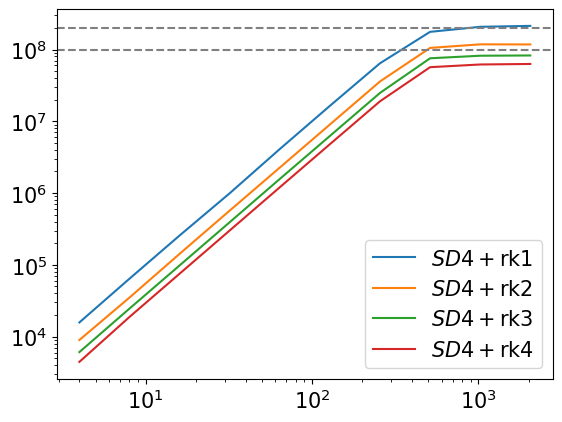

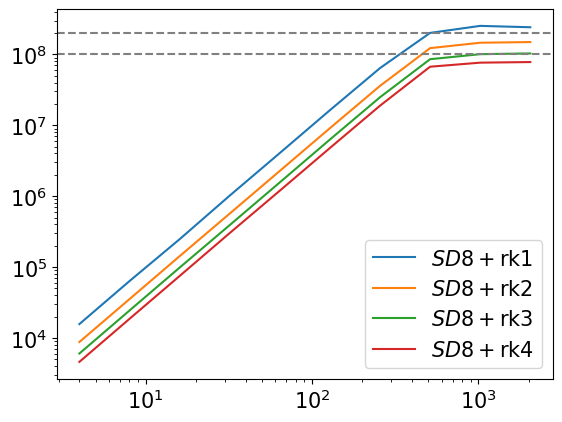

In [12]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    fig,axs=plt.subplots(1,1)
    for t_int in ["rk1","rk2","rk3","rk4"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
    plt.axhline(1E+8,ls="--",color="gray")
    plt.axhline(2E+8,ls="--",color="gray")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()

In [13]:
compute_times("rk1",[1],n,100,"FV")

1 4
t=0.0, steps taken 100, time taken 0.39, bzcps = 0.0
1 8
t=0.0, steps taken 100, time taken 0.379, bzcps = 0.0
1 16
t=0.0, steps taken 100, time taken 0.373, bzcps = 0.0
1 32
t=0.0, steps taken 100, time taken 0.374, bzcps = 0.0
1 64
t=0.0, steps taken 100, time taken 0.371, bzcps = 0.001
1 128
t=0.0, steps taken 100, time taken 0.376, bzcps = 0.004
1 256
t=0.0, steps taken 100, time taken 0.382, bzcps = 0.017
1 512
t=0.0, steps taken 100, time taken 0.383, bzcps = 0.068
1 1024
t=0.0, steps taken 100, time taken 0.627, bzcps = 0.167
1 2048
t=0.0, steps taken 100, time taken 2.353, bzcps = 0.178


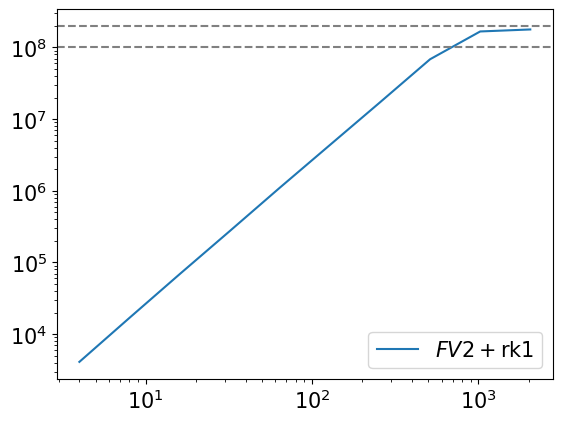

In [14]:
Ns = 2**(2+np.arange(n))
for p in [1]:
    fig,axs=plt.subplots(1,1)
    for t_int in ["rk1"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$FV{p+1}+${t_int}")
    plt.axhline(1E+8,ls="--",color="gray")
    plt.axhline(2E+8,ls="--",color="gray")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()